In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import numpy as np

from student_client import create_student_gym_env

env = create_student_gym_env(user_token='keyvanatt')
env.reset()

2026-03-06 10:50:59,216 - student_client.student_gym_env - WARNING - No .env file found and no explicit parameters provided. Using default values. For better setup, create a .env file with:
SERVER_URL=http://rlchallenge.orailix.com
USER_TOKEN=student_user
ENV_TYPE=DegradationEnv
MAX_STEPS_PER_EPISODE=1000
AUTO_RESET=True
TIMEOUT=30.0
2026-03-06 10:50:59,564 - student_client.student_gym_env - INFO - Client is up to date (version 0.4)
2026-03-06 10:50:59,639 - student_client.student_gym_env - INFO - Created new session: 5953ce9b-e723-42c8-9150-6c1fbb1959cc
2026-03-06 10:51:01,039 - student_client.student_gym_env - INFO - Created new episode: e8df7394-ed3b-43aa-a0b7-5f406d038e3f
2026-03-06 10:51:01,039 - student_client.student_gym_env - INFO - StudentGymEnv initialized with episode e8df7394-ed3b-43aa-a0b7-5f406d038e3f
2026-03-06 10:51:02,523 - student_client.student_gym_env - INFO - 🔄 Episode ID changed from e8df7394-ed3b-43aa-a0b7-5f406d038e3f to c9763fbe-5a8a-41c3-b24a-958110b27cec (old

(array([7.9840985e+02, 1.9430537e+04, 3.3648126e+02, 1.1229164e+03,
        3.7266576e-01, 1.3663756e+06, 3.9616145e+03, 0.0000000e+00,
        1.0351787e+01], dtype=float32),
 {'step': 0,
  'episode_id': 'c9763fbe-5a8a-41c3-b24a-958110b27cec',
  'terminated': False,
  'truncated': False})

In [4]:
# Reset environment to get initial observation
obs, info = env.reset()
print(f"📋 Starting episode {info.get('episode_id', 'unknown')}")

obs.shape, info

2026-03-06 10:51:04,204 - student_client.student_gym_env - INFO - 🔄 Episode ID changed from c9763fbe-5a8a-41c3-b24a-958110b27cec to 9a12bc63-ace6-431f-bde8-970b82995ef4 (old episode had steps)
2026-03-06 10:51:04,206 - student_client.student_gym_env - INFO - Episode 9a12bc63-ace6-431f-bde8-970b82995ef4 reset successfully


📋 Starting episode 9a12bc63-ace6-431f-bde8-970b82995ef4


((9,),
 {'step': 0,
  'episode_id': '9a12bc63-ace6-431f-bde8-970b82995ef4',
  'terminated': False,
  'truncated': False})

In [5]:
# Initialize data collection arrays
observations = []
actions = []
rewards = []
total_timesteps = 0

for step in range(50):

    # Choose a random action (0=do nothing, 1=repair, 2=sell)
    if step >= 25:
        action = 2  # Sell after 30 steps
    elif step % 5 == 0 and step > 0:  # Repair every 5 steps
        action = 1
    else:
        action = 0
    print(f"Step {step}: Action: {action}")

    # Take step in environment
    obs_result, reward, terminated, truncated, info = env.step(
        action=action,
    )

    print(f'obs_result: {obs_result.shape}')

    observations.append(obs_result)
    actions.append(action)

    rewards.append(reward)

    # Update total timesteps - server advances by step_size but returns only final observation
    total_timesteps = info['step']

    # Print progress every step
    if step % 1 == 0:
        print(f" Step {total_timesteps}: Reward={reward:.2f}, Total={sum(rewards):.2f}")

    # Check if episode ended
    if terminated or truncated:
        print(f"🏁 Episode ended at step {total_timesteps} with reward={reward:.2f}")
        break


# Print summary statistics
total_reward = sum(rewards)
print(f"\n Episode Summary:")
print(f"   Total Steps: {len(actions)}")
print(f"   Total Reward: {total_reward:.2f}")
print(f"   Actions Taken: {len([a for a in actions if a == 1])} repairs, {len([a for a in actions if a == 2])} sell")

Step 0: Action: 0
obs_result: (10, 9)
 Step 10: Reward=453.11, Total=453.11
Step 1: Action: 0
obs_result: (10, 9)
 Step 20: Reward=408.55, Total=861.67
Step 2: Action: 0
obs_result: (10, 9)
 Step 30: Reward=373.17, Total=1234.84
Step 3: Action: 0
obs_result: (10, 9)
 Step 40: Reward=327.46, Total=1562.30
Step 4: Action: 0
obs_result: (10, 9)
 Step 50: Reward=304.64, Total=1866.95
Step 5: Action: 1
obs_result: (10, 9)
 Step 60: Reward=-520.04, Total=1346.91
Step 6: Action: 0
obs_result: (10, 9)
 Step 70: Reward=408.79, Total=1755.70
Step 7: Action: 0
obs_result: (10, 9)
 Step 80: Reward=360.30, Total=2116.00
Step 8: Action: 0
obs_result: (10, 9)
 Step 90: Reward=290.23, Total=2406.23
Step 9: Action: 0
obs_result: (10, 9)
 Step 100: Reward=254.15, Total=2660.39
Step 10: Action: 1
obs_result: (10, 9)
 Step 110: Reward=-520.45, Total=2139.93
Step 11: Action: 0
obs_result: (10, 9)
 Step 120: Reward=368.20, Total=2508.13
Step 12: Action: 0
obs_result: (10, 9)
 Step 130: Reward=324.76, Total=

In [28]:
# Finish episode
env.close()

2026-03-05 22:25:30,072 - student_client.student_gym_env - INFO - Closed environment f4a495a0-ef00-4b48-beb6-bfb92d792431


In [29]:
len(observations), len(actions)

(30, 30)

In [30]:
observations

[array([[7.9347852e+02, 1.9339176e+04, 3.3463004e+02, 1.1166864e+03,
         3.7133142e-01, 1.3644088e+06, 3.9509597e+03, 0.0000000e+00,
         9.1000004e+00],
        [7.9468323e+02, 1.9399135e+04, 3.3468164e+02, 1.1175105e+03,
         3.7148768e-01, 1.3661078e+06, 3.9509871e+03, 0.0000000e+00,
         9.1000004e+00],
        [7.9720270e+02, 1.9403107e+04, 3.3535349e+02, 1.1189460e+03,
         3.7183765e-01, 1.3730508e+06, 3.9551987e+03, 0.0000000e+00,
         9.5984621e+00],
        [7.9469165e+02, 1.9360396e+04, 3.3521539e+02, 1.1186484e+03,
         3.7174949e-01, 1.3636885e+06, 3.9543354e+03, 0.0000000e+00,
         9.4962187e+00],
        [7.9489935e+02, 1.9357475e+04, 3.3510626e+02, 1.1181300e+03,
         3.7164906e-01, 1.3661542e+06, 3.9537690e+03, 0.0000000e+00,
         9.5005245e+00],
        [7.9733691e+02, 1.9359396e+04, 3.3556644e+02, 1.1188521e+03,
         3.7185004e-01, 1.3748915e+06, 3.9567563e+03, 0.0000000e+00,
         9.5781813e+00],
        [7.9543823e+02

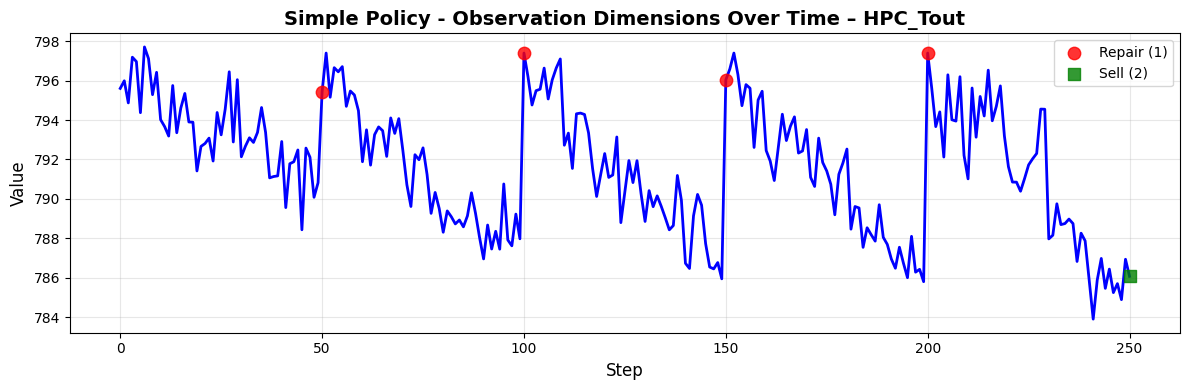

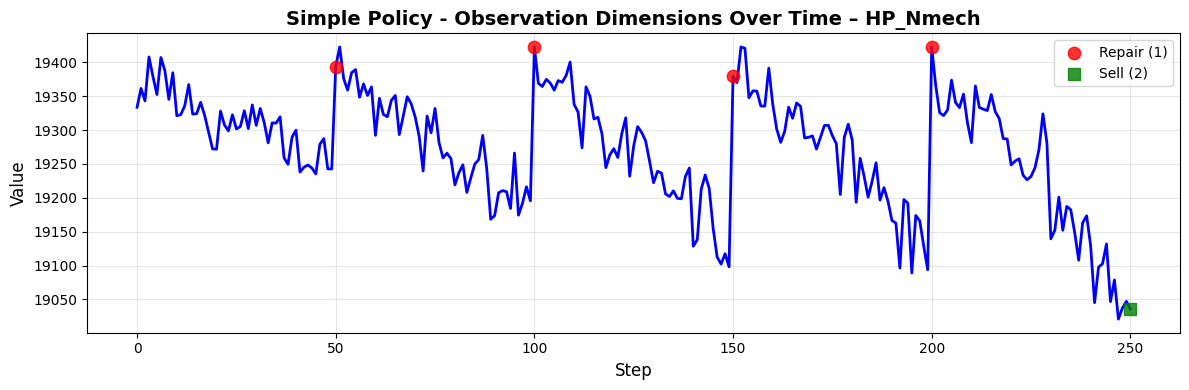

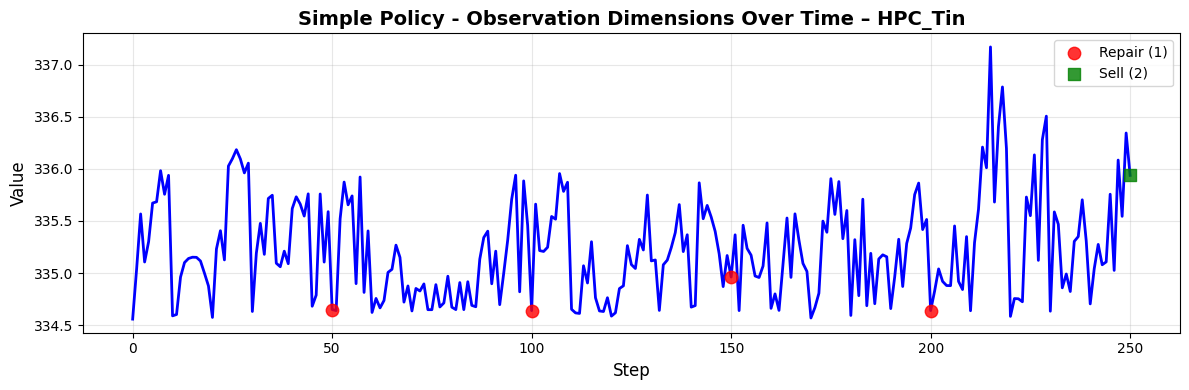

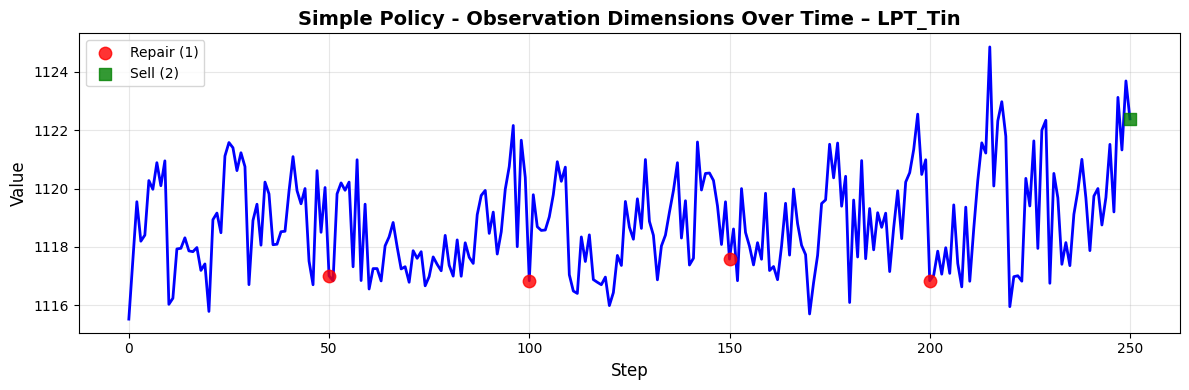

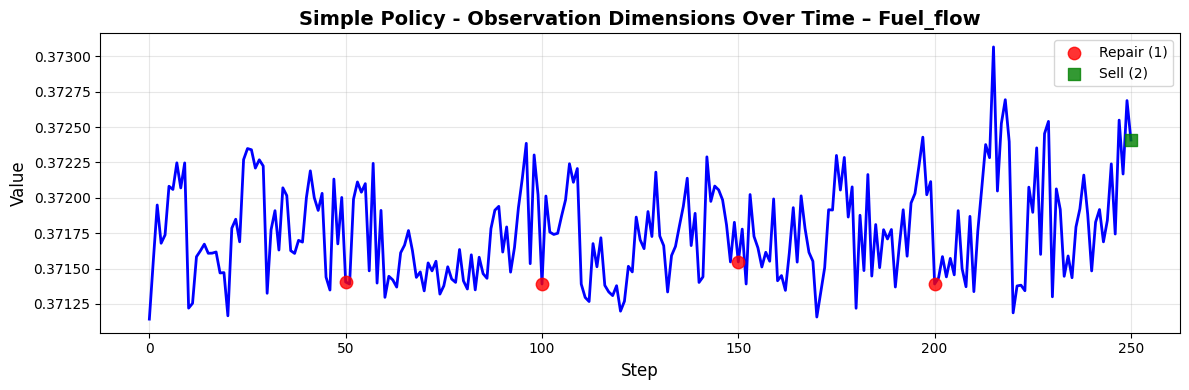

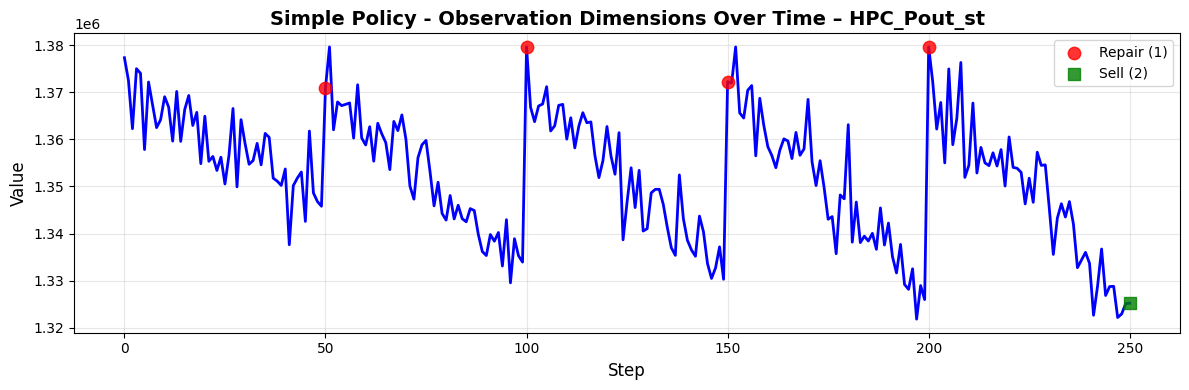

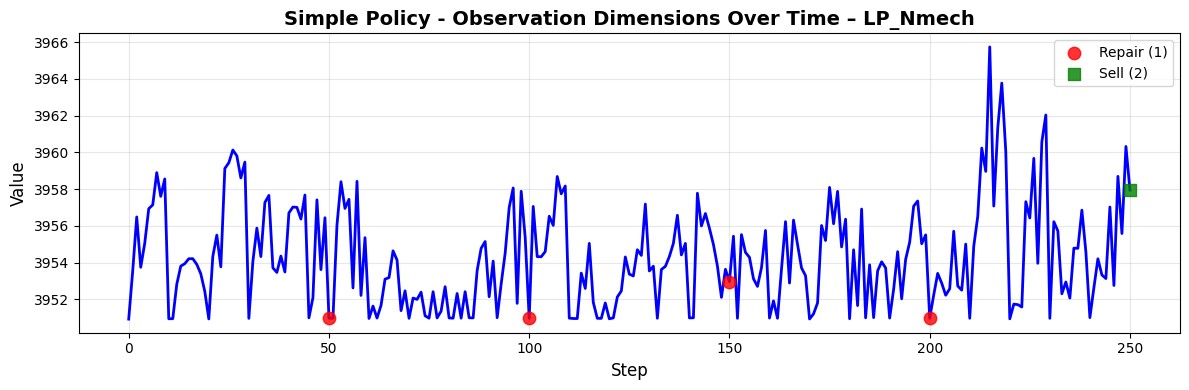

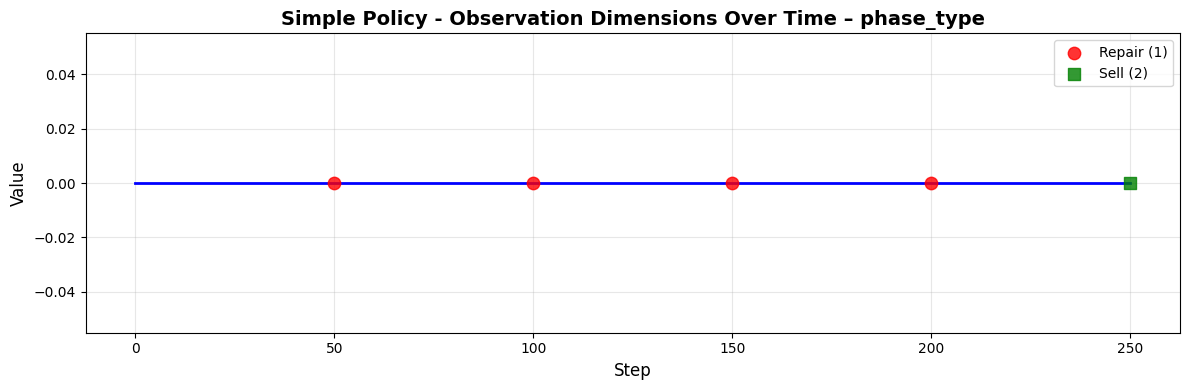

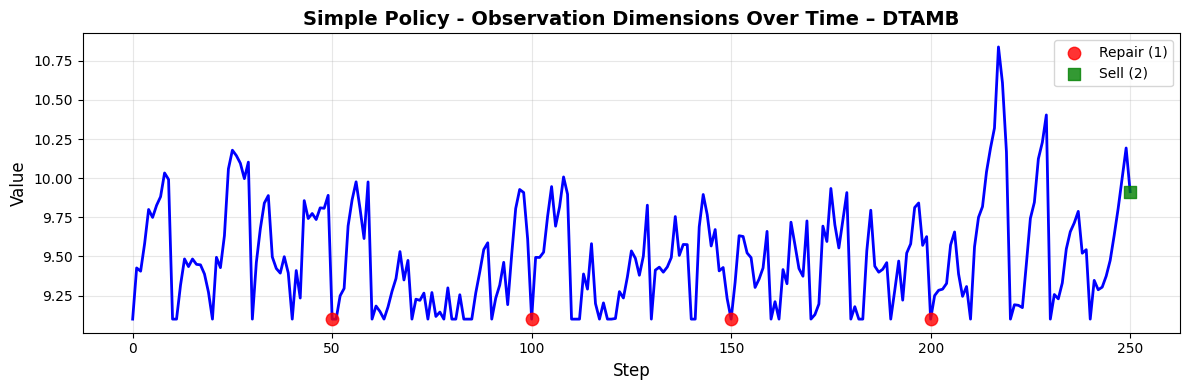

In [40]:
from student_client.plotting import plot_observations


plot_observations(
        observations=observations,
        actions=actions,
        title="Simple Policy - Observation Dimensions Over Time"
    )

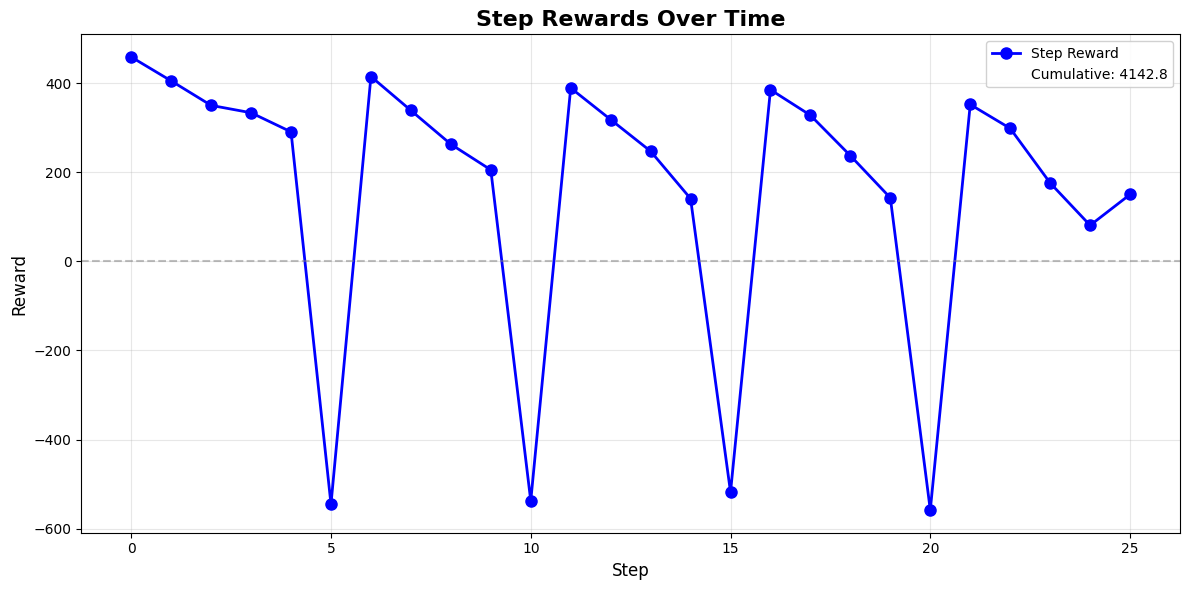

📊 Reward Statistics:
   Total Steps: 26
   Total Reward: 4142.78
   Average Reward: 159.34
   Max Reward: 458.37
   Min Reward: -557.94


In [41]:
from student_client.plotting import plot_rewards

plot_rewards(rewards=rewards)